# Tutorial

In [1]:
from ReflectX import *

## Loading a full model

The most basic model is for one planet type, star type, and C/O ratio.  This function loads every spectrum for that system, stored as a dictionary of XArrays. Example: load every spectrum for a Saturn-like planet at sub-solar C/O around an M dwarf star:

In [2]:
path = '/Volumes/Oy/ReflectX/ReflectXGasGiantGrid-R1000/' # Path to the location of the Teff folders:
Teff = 3500
Planet = 'Saturn'
CtoO = 0.5
Teq = 100
system_model = LoadModel(path, Teff, Planet, CtoO, Teq)

In [3]:
system_model.keys()

dict_keys(['teq100/phase0/cloudfree', 'teq100/phase0/fsed01/kzz1e+09', 'teq100/phase0/fsed01/kzz1e+11', 'teq100/phase0/fsed05/kzz1e+09', 'teq100/phase0/fsed05/kzz1e+11', 'teq100/phase0/fsed1/kzz1e+09', 'teq100/phase0/fsed1/kzz1e+11', 'teq100/phase0/fsed3/kzz1e+09', 'teq100/phase0/fsed3/kzz1e+11', 'teq100/phase0/fsed6/kzz1e+09', 'teq100/phase0/fsed6/kzz1e+11', 'teq100/phase0/fsed10/kzz1e+09', 'teq100/phase0/fsed10/kzz1e+11', 'teq100/phase45/cloudfree', 'teq100/phase45/fsed01/kzz1e+09', 'teq100/phase45/fsed01/kzz1e+11', 'teq100/phase45/fsed05/kzz1e+09', 'teq100/phase45/fsed05/kzz1e+11', 'teq100/phase45/fsed1/kzz1e+09', 'teq100/phase45/fsed1/kzz1e+11', 'teq100/phase45/fsed3/kzz1e+09', 'teq100/phase45/fsed3/kzz1e+11', 'teq100/phase45/fsed6/kzz1e+09', 'teq100/phase45/fsed6/kzz1e+11', 'teq100/phase45/fsed10/kzz1e+09', 'teq100/phase45/fsed10/kzz1e+11', 'teq100/phase90/cloudfree', 'teq100/phase90/fsed01/kzz1e+09', 'teq100/phase90/fsed01/kzz1e+11', 'teq100/phase90/fsed05/kzz1e+09', 'teq100/phas

You can then access individual spectrum XArrays through the dictionary keyword. 

Example: to see the spectra for this planet at equil temp of 100K at quadrature with no clouds:

In [4]:
phase = 90
clouds = 'cloudfree'
system_model['teq{}/phase{}/{}'.format(Teq,phase,clouds)]

<xarray.Dataset> Size: 77kB
Dimensions:      (wavelength: 1899, pressure: 91)
Coordinates:
  * wavelength   (wavelength) float64 15kB 0.3 0.3003 0.3006 ... 1.998 2.0 2.002
  * pressure     (pressure) float64 728B 1e-06 1.243e-06 ... 254.4 316.2
Data variables:
    starflux     (wavelength) float64 15kB ...
    albedo       (wavelength) float64 15kB ...
    fpfs         (wavelength) float64 15kB ...
    planetflux   (wavelength) float64 15kB ...
    temperature  (pressure) float64 728B ...
Attributes: (12/42)
    ReflectX.Model:                                  ReflectX Gas Giant Plane...
    modeltype:                                      GasGiant
    wavelength.range:                               [0.3, 2]
    star.teff:                                      3500
    star.radius:                                    0.45
    star.radius.unit:                               Rsun
    ...                                             ...
    ntangle:                                        6
    ngangle:                                        6
    cloud.species:                                  none
    spectral.resolution:                            1,000
    fsed:                                           nan
    kzz:                                            nan

Or with thick fluffy clouds with weak vertical mixing:

In [5]:
phase = 90
fsed = str(0.1).replace('.','') # <- fsed 0.1 and 0.5 are stored with keywords 01 and 05
kzz = 1e11 # <- kzz's use keyword 1e+09 and 1e+11
system_model['teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,fsed,kzz)]

<xarray.Dataset> Size: 77kB
Dimensions:      (wavelength: 1899, pressure: 91)
Coordinates:
  * wavelength   (wavelength) float64 15kB 0.3 0.3003 0.3006 ... 1.998 2.0 2.002
  * pressure     (pressure) float64 728B 1e-06 1.243e-06 ... 254.4 316.2
Data variables:
    starflux     (wavelength) float64 15kB ...
    albedo       (wavelength) float64 15kB ...
    fpfs         (wavelength) float64 15kB ...
    planetflux   (wavelength) float64 15kB ...
    temperature  (pressure) float64 728B ...
Attributes: (12/42)
    ReflectX.Model:                                  ReflectX Gas Giant Plane...
    modeltype:                                      GasGiant
    wavelength.range:                               [0.3, 2]
    star.teff:                                      3500
    star.radius:                                    0.45
    star.radius.unit:                               Rsun
    ...                                             ...
    ntangle:                                        6
    ngangle:                                        6
    cloud.species:                                  ['H2O', 'KCl', 'NH3', 'Na...
    spectral.resolution:                            1,000
    fsed:                                           0.1
    kzz:                                            1e+11

## Loading individual spectrum XArrays

Alternatively you can load one XArray directly by suppying keywords to LoadModel:

In [6]:
path = '/Volumes/Oy/ReflectX/ReflectXGasGiantGrid-R1000/'
Teff = 3500
planet = 'Saturn'
CtoO = 0.5
Teq = 150
# Leaving the "clouds" keyword empyt automatically loads a cloudfree model
model = LoadModel(path, Teff, planet, CtoO, Teq, phase = 90)
model

<xarray.Dataset> Size: 77kB
Dimensions:      (wavelength: 1899, pressure: 91)
Coordinates:
  * wavelength   (wavelength) float64 15kB 0.3 0.3003 0.3006 ... 1.998 2.0 2.002
  * pressure     (pressure) float64 728B 1e-06 1.243e-06 ... 254.4 316.2
Data variables:
    starflux     (wavelength) float64 15kB ...
    albedo       (wavelength) float64 15kB ...
    fpfs         (wavelength) float64 15kB ...
    planetflux   (wavelength) float64 15kB ...
    temperature  (pressure) float64 728B ...
Attributes: (12/42)
    ReflectX.Model:                                  ReflectX Gas Giant Plane...
    modeltype:                                      GasGiant
    wavelength.range:                               [0.3, 2]
    star.teff:                                      3500
    star.radius:                                    0.45
    star.radius.unit:                               Rsun
    ...                                             ...
    ntangle:                                        6
    ngangle:                                        6
    cloud.species:                                  none
    spectral.resolution:                            1,000
    fsed:                                           nan
    kzz:                                            nan

Or you can load cloudy models by supplying a dictionary with cloud parameters:

In [7]:
path = '/Volumes/Oy/ReflectX/ReflectXGasGiantGrid-R1000/'
Teff = 3500
planet = 'Saturn'
CtoO = 0.5
Teq = 150
model = LoadModel(path, Teff, planet, CtoO, Teq, phase = 90, clouds = {'fsed':0.1, 'kzz':1e11})
model

<xarray.Dataset> Size: 77kB
Dimensions:      (wavelength: 1899, pressure: 91)
Coordinates:
  * wavelength   (wavelength) float64 15kB 0.3 0.3003 0.3006 ... 1.998 2.0 2.002
  * pressure     (pressure) float64 728B 1e-06 1.243e-06 ... 254.4 316.2
Data variables:
    starflux     (wavelength) float64 15kB ...
    albedo       (wavelength) float64 15kB ...
    fpfs         (wavelength) float64 15kB ...
    planetflux   (wavelength) float64 15kB ...
    temperature  (pressure) float64 728B ...
Attributes: (12/42)
    ReflectX.Model:                                  ReflectX Gas Giant Plane...
    modeltype:                                      GasGiant
    wavelength.range:                               [0.3, 2]
    star.teff:                                      3500
    star.radius:                                    0.45
    star.radius.unit:                               Rsun
    ...                                             ...
    ntangle:                                        6
    ngangle:                                        6
    cloud.species:                                  ['H2O', 'KCl', 'MnS', 'Na...
    spectral.resolution:                            1,000
    fsed:                                           0.1
    kzz:                                            1e+11

## Anatomy of the XArrays

Each spectrum is stored as an XArray.  XArrays provide details and a reference dimension, in this case all spectra are referenced to the "wavelength" coordinate.

Each XArray contains a stellar spectrum, a planet albedo spectrum, a planet/star contrast ratio spectrum (called 'fpfs'), and a planet flux spectrum (where planet flux = fpfs * star flux). Flux spectra are from the surface of the planet/star.

Each cooridnate and data variable is accessed through the relevant keyword.

The unit for each cooridinate and data variable is shown by toggling the paper icon next to the variable and accessed through dot or keyword notation

In [8]:
path = '/Volumes/Oy/ReflectX/ReflectXGasGiantGrid-R1000/'
Teq = 150
Teff = 3500
planet = 'Saturn'
CtoO = 0.5
model = LoadModel(path, Teff, planet, CtoO, Teq, phase = 90, clouds = {'fsed':1, 'kzz':1e11})

In [9]:
model

<xarray.Dataset> Size: 77kB
Dimensions:      (wavelength: 1899, pressure: 91)
Coordinates:
  * wavelength   (wavelength) float64 15kB 0.3 0.3003 0.3006 ... 1.998 2.0 2.002
  * pressure     (pressure) float64 728B 1e-06 1.243e-06 ... 254.4 316.2
Data variables:
    starflux     (wavelength) float64 15kB ...
    albedo       (wavelength) float64 15kB ...
    fpfs         (wavelength) float64 15kB ...
    planetflux   (wavelength) float64 15kB ...
    temperature  (pressure) float64 728B ...
Attributes: (12/42)
    ReflectX.Model:                                  ReflectX Gas Giant Plane...
    modeltype:                                      GasGiant
    wavelength.range:                               [0.3, 2]
    star.teff:                                      3500
    star.radius:                                    0.45
    star.radius.unit:                               Rsun
    ...                                             ...
    ntangle:                                        6
    ngangle:                                        6
    cloud.species:                                  ['H2O', 'KCl', 'MnS', 'Na...
    spectral.resolution:                            1,000
    fsed:                                           1
    kzz:                                            1e+11

In [10]:
model.fpfs.units, model['fpfs'].units

('erg/cm**2/s/cm/', 'erg/cm**2/s/cm/')

Text(0, 0.5, '$F_p / F_*$ [erg/cm**2/s/cm/]')

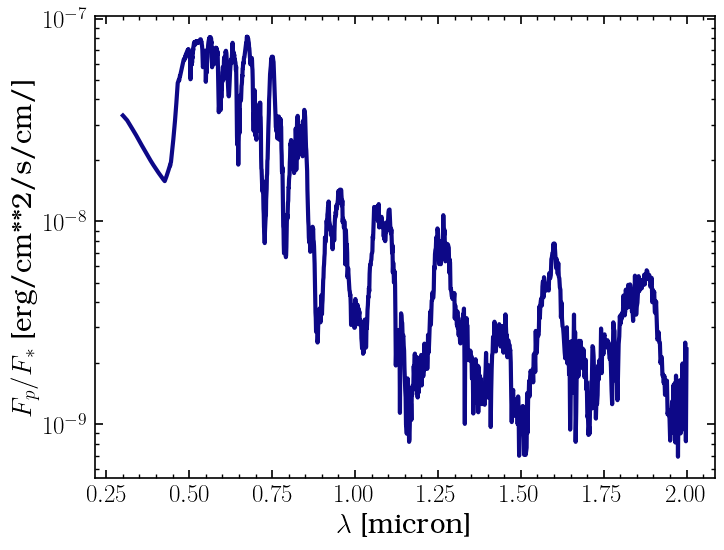

In [11]:
plt.semilogy(model.wavelength, model.fpfs)
plt.xlabel('$\\lambda$ [{}]'.format(model.wavelength.units))
plt.ylabel('$F_p / F_*$ [{}]'.format(model.fpfs.units))

They also contain a set of attributes outlining every parameter used to generate the model, accessed via .attrs

In [12]:
model.attrs

{'ReflectX.Model': ' ReflectX Gas Giant Planet Reflected Light PICASO model spectra  for a world with r=0.8, m=0.3 with 3500K/0.45Rsun/logg4.8 star at 0.5 au  Spectra are R=1,000; to get a different gridding use ReflectX.MeanRegrid  Column [0] is wavelength in microns; columns labeled  "fpfs" are the planet/star flux ratio spectrum, columns labeled "PlanetFlux" are the planet spectrum only All flux in units of ergs cm$^{-2}$ s$^{-1}$ cm$^{-1}$  Created 2026-08-13 by Logan Pearce',
 'modeltype': 'GasGiant',
 'wavelength.range': '[0.3, 2]',
 'star.teff': 3500,
 'star.radius': 0.45,
 'star.radius.unit': 'Rsun',
 'star.logg': '4.8',
 'star.metallicity': '1',
 'star.star.model.database': 'phoenix',
 'star.mass': 0.44,
 'planet.custom.pt.profile.dataframe': 'none',
 'planet.gravity': 1161.868100444491,
 'planet.gravity.unit': 'cm/(s**2)',
 'planet.radius': 0.8,
 'planet.radius.unit': 'Rjup',
 'planet.mass': 0.3,
 'planet.mass.unit': 'Mjup',
 'planet.tint': '150',
 'planet.separation': 0.48,


And you can call the attributes and use them in plots and calculations

Text(0.1, 0.1, 'T_eq = 150 K \n Sep = 0.5 au \n Phase = 90 deg \n f_sed = 1 \n Kzz = 1e+11')

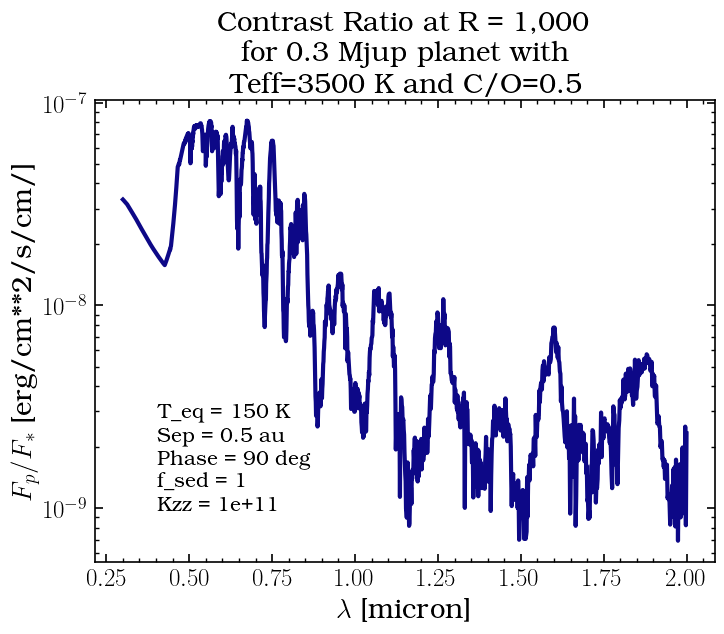

In [15]:
plt.semilogy(model.wavelength, model.fpfs)
plt.xlabel('$\\lambda$ [{}]'.format(model.wavelength.units))
plt.ylabel('$F_p / F_*$ [{}]'.format(model.fpfs.units))
plt.title('Contrast Ratio at R = {} \n for {} Mjup planet with \n Teff={} K and C/O={}'.format(model.attrs['spectral.resolution'],
                                                                                          model.attrs['planet.mass'],
                                                                                         model.attrs['star.teff'],
                                                                                         model.attrs['planet.ctoo']))
plt.annotate('T_eq = {0} K \n Sep = {1:.1f} {2} \n Phase = {3} deg \n f_sed = {4} \n Kzz = {5}'.format(
    model.attrs['planet.teq'], 
    model.attrs['planet.separation'], 
    model.attrs['planet.separation.unit'],
    model.attrs['phase'],
    model.attrs['fsed'],
    model.attrs['kzz']
),
            xy = (0.1,0.1), xycoords='axes fraction', va='bottom', fontsize=15)

The XArray also contains the pressure/temperature profile:

Text(0, 0.5, 'Pressure[bar]')

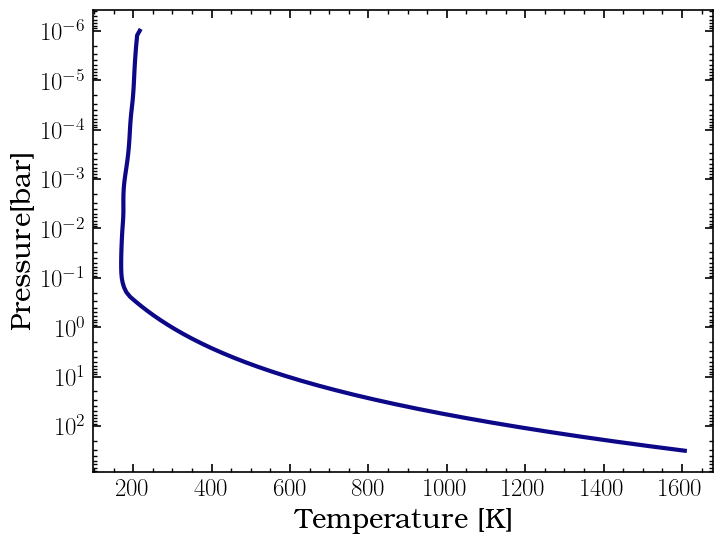

In [18]:
plt.semilogy(model.temperature, model.pressure)
plt.gca().invert_yaxis()
plt.gca().set_yscale('log')
plt.xlabel('Temperature [{}]'.format(model.temperature.attrs['units']))
plt.ylabel('Pressure[{}]'.format(model.pressure.attrs['units']))

## You can easily compare among properties

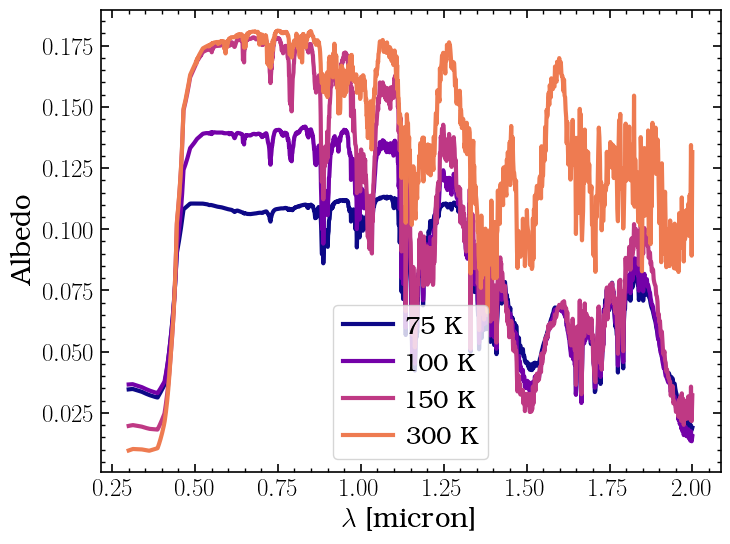

In [21]:
path = '/Volumes/Oy/ReflectX/ReflectXGasGiantGrid-R1000/'
Teff = 3500
Planet = 'Jupiter'
CtoO = 0.5
# Select some temperatures:
teqs = [75, 100, 150, 300]
# and phase and cloud properties:
phase = 90
fsed = 1
kzz = 1e9
# make an empty dictionary:
models = {}

for Teq in teqs:
    # Load selected models into dictionary:
    model = LoadModel(path, Teff, Planet, CtoO, Teq)
    key = 'teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,fsed,kzz)
    models.update({key:model[key]})

fig,ax = plt.subplots()
for key in models.keys():
    ax.plot(models[key].wavelength, models[key].albedo, label='{} K'.format(models[key].attrs['planet.teq']))
ax.set_xlabel('$\\lambda$ [{}]'.format(models[key].wavelength.units))
ax.set_ylabel('Albedo')
plt.legend()

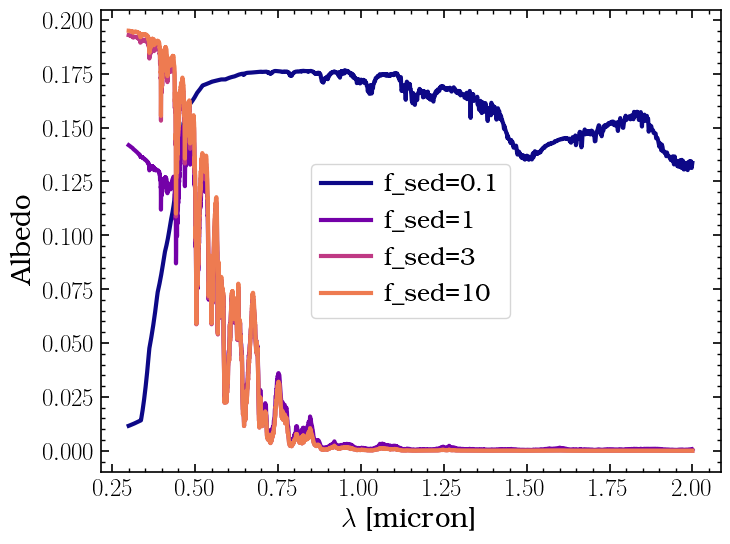

In [26]:
## Or different cloud sedimentation:
Teq = 150
phase = 90
fseds = [0.1,1,3,10]
kzz = 1e11

models = {}
for fsed in fseds:
    # Load selected models into dictionary:
    model = LoadModel(path, Teff, Planet, CtoO, Teq)
    key = 'teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,str(fsed).replace('.',''),kzz)
    models.update({key:model[key]})

fig,ax = plt.subplots()
for fsed in fseds:
    key = 'teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,str(fsed).replace('.',''),kzz)
    ax.plot(models[key].wavelength, models[key].albedo, label='f_sed={}'.format(models[key].attrs['fsed']))
ax.set_xlabel('$\\lambda$ [{}]'.format(models[key].wavelength.units))
ax.set_ylabel('Albedo')
plt.legend()

In [30]:
model = LoadModel(path, Teff, Planet, CtoO, Teq)
model.keys()

dict_keys(['teq150/phase0/cloudfree', 'teq150/phase0/fsed01/kzz1e+09', 'teq150/phase0/fsed01/kzz1e+11', 'teq150/phase0/fsed05/kzz1e+09', 'teq150/phase0/fsed05/kzz1e+11', 'teq150/phase0/fsed1/kzz1e+09', 'teq150/phase0/fsed1/kzz1e+11', 'teq150/phase0/fsed3/kzz1e+09', 'teq150/phase0/fsed3/kzz1e+11', 'teq150/phase0/fsed6/kzz1e+09', 'teq150/phase0/fsed6/kzz1e+11', 'teq150/phase0/fsed10/kzz1e+09', 'teq150/phase0/fsed10/kzz1e+11', 'teq150/phase45/cloudfree', 'teq150/phase45/fsed01/kzz1e+09', 'teq150/phase45/fsed01/kzz1e+11', 'teq150/phase45/fsed05/kzz1e+09', 'teq150/phase45/fsed05/kzz1e+11', 'teq150/phase45/fsed1/kzz1e+09', 'teq150/phase45/fsed1/kzz1e+11', 'teq150/phase45/fsed3/kzz1e+09', 'teq150/phase45/fsed3/kzz1e+11', 'teq150/phase45/fsed6/kzz1e+09', 'teq150/phase45/fsed6/kzz1e+11', 'teq150/phase45/fsed10/kzz1e+09', 'teq150/phase45/fsed10/kzz1e+11', 'teq150/phase90/cloudfree', 'teq150/phase90/fsed01/kzz1e+09', 'teq150/phase90/fsed01/kzz1e+11', 'teq150/phase90/fsed05/kzz1e+09', 'teq150/phas

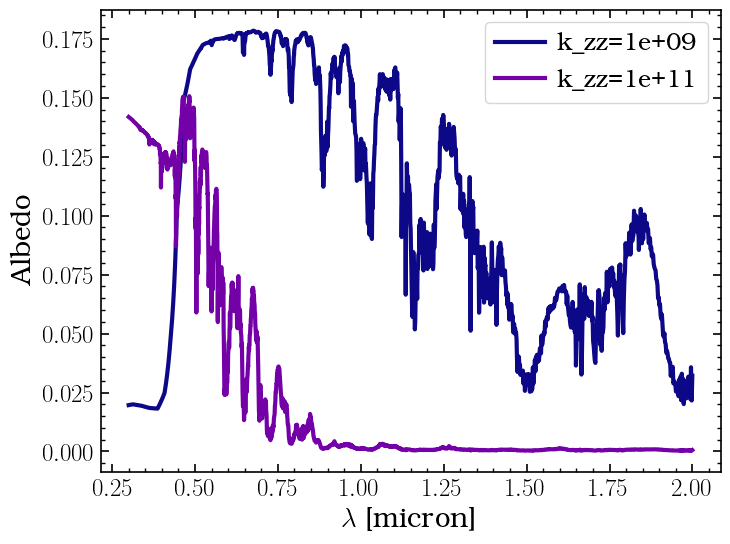

In [34]:
Teq = 150
phase = 90
fsed = 1
kzzs = [1e9,1e11]

models = {}
for kzz in kzzs:
    # Load selected models into dictionary:
    model = LoadModel(path, Teff, Planet, CtoO, Teq)
    key = 'teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,str(fsed).replace('.',''),kzz)
    models.update({key:model[key]})

fig,ax = plt.subplots()
for kzz in kzzs:
    key = 'teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,str(fsed).replace('.',''),kzz)
    ax.plot(models[key].wavelength, models[key].albedo, label='k_zz={}'.format(models[key].attrs['kzz']))
ax.set_xlabel('$\\lambda$ [{}]'.format(models[key].wavelength.units))
ax.set_ylabel('Albedo')
plt.legend()


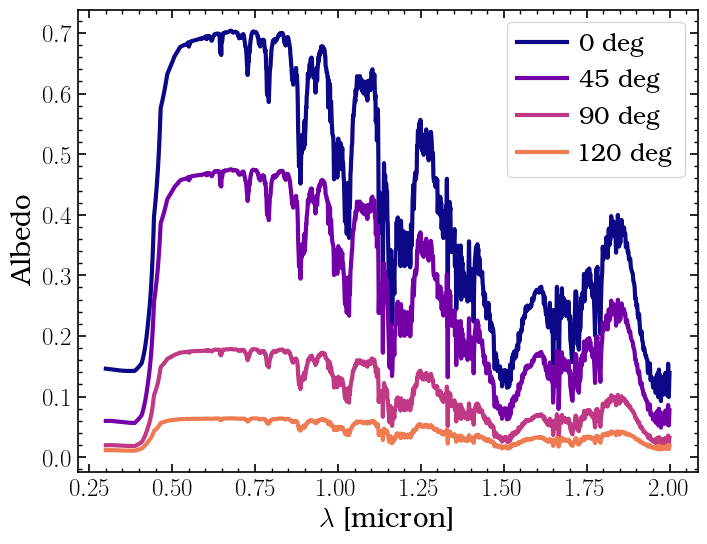

In [38]:
Teq = 150
phases = [0,45,90,120]
fseds = 1
kzz = 1e9

models = {}
for phase in phases:
    # Load selected models into dictionary:
    model = LoadModel(path, Teff, Planet, CtoO, Teq)
    key = 'teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,str(fsed).replace('.',''),kzz)
    models.update({key:model[key]})

fig,ax = plt.subplots()
for phase in phases:
    key = 'teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,str(fsed).replace('.',''),kzz)
    ax.plot(models[key].wavelength, models[key].albedo, label='{} deg'.format(models[key].attrs['phase']))
ax.set_xlabel('$\\lambda$ [{}]'.format(models[key].wavelength.units))
ax.set_ylabel('Albedo')
plt.legend()



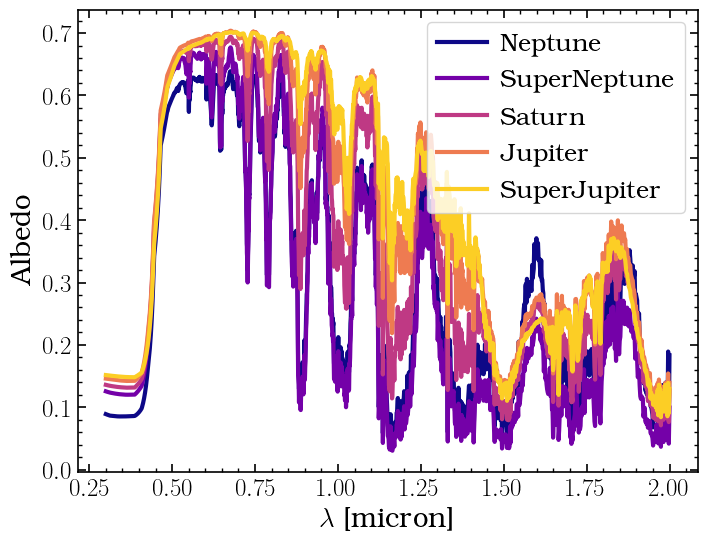

In [41]:

Teff = 3500
planets = ['Neptune','SuperNeptune','Saturn','Jupiter','SuperJupiter']
CtoO = 0.5
Teq = 150
phase = 0
fseds = 1
kzz = 1e9

models = {}
for Planet in planets:
    # Load selected models into dictionary:
    model = LoadModel(path, Teff, Planet, CtoO, Teq)
    key = 'teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,str(fsed).replace('.',''),kzz)
    models.update({Planet+key:model[key]})

fig,ax = plt.subplots()
for Planet in planets:
    key = Planet+'teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,str(fsed).replace('.',''),kzz)
    ax.plot(models[key].wavelength, models[key].albedo, label='{}'.format(models[key].attrs['planet.type']))
ax.set_xlabel('$\\lambda$ [{}]'.format(models[key].wavelength.units))
ax.set_ylabel('Albedo')
plt.legend()



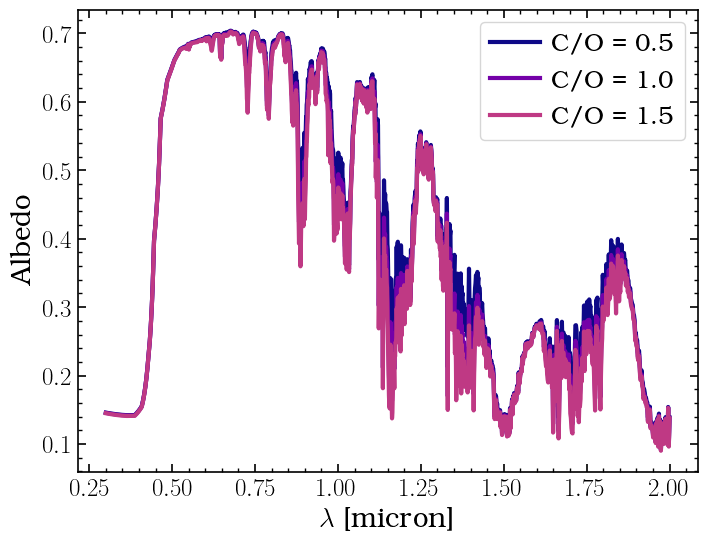

In [44]:
Teff = 3500
Planet = 'Jupiter'
Teq = 150
phase = 0
fseds = 1
kzz = 1e9
CtoOs = [0.5,1.0,1.5]

models = {}
for CtoO in CtoOs:
    # Load selected models into dictionary:
    model = LoadModel(path, Teff, Planet, CtoO, Teq)
    key = 'teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,str(fsed).replace('.',''),kzz)
    models.update({str(CtoO)+key:model[key]})

fig,ax = plt.subplots()
for CtoO in CtoOs:
    key = str(CtoO)+'teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,str(fsed).replace('.',''),kzz)
    ax.plot(models[key].wavelength, models[key].albedo, label='C/O = {}'.format(models[key].attrs['planet.ctoo']))
ax.set_xlabel('$\\lambda$ [{}]'.format(models[key].wavelength.units))
ax.set_ylabel('Albedo')
plt.legend()

## You can regrid the spectrum onto a lower resolution using the built in MeanRegrid function

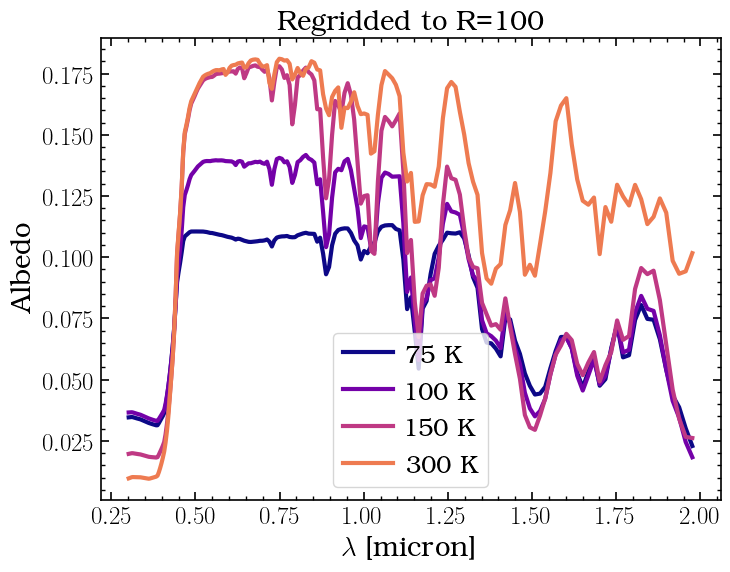

In [25]:
path = '/Volumes/Oy/ReflectX/ReflectXGasGiantGrid-R1000/'
Teff = 3500
Planet = 'Jupiter'
CtoO = 0.5
# Select some temperatures:
teqs = [75, 100, 150, 300]
# and phase and cloud properties:
phase = 90
fsed = 1
kzz = 1e9
# make an empty dictionary:
models = {}

for Teq in teqs:
    # Load selected models into dictionary:
    model = LoadModel(path, Teff, Planet, CtoO, Teq)
    key = 'teq{}/phase{}/fsed{}/kzz{:.0e}'.format(Teq,phase,fsed,kzz)
    models.update({key:model[key]})

fig,ax = plt.subplots()
for key in models.keys():
    wav,alb = MeanRegrid(models[key].wavelength, models[key].albedo, R = 100)
    ax.plot(wav, alb, label='{} K'.format(models[key].attrs['planet.teq']))
ax.set_xlabel('$\\lambda$ [{}]'.format(models[key].wavelength.units))
ax.set_ylabel('Albedo')
ax.set_title('Regridded to R=100')
plt.legend()

## Filters

We also supply a set of pre-loaded Sloan SDSS prime filters and MKO J and H, as they appear on NIRC2, also stored as an XArray. 

In [45]:
filters = LoadFilters()
filters

<xarray.Dataset> Size: 11MB
Dimensions:     (wavelength: 189711, vegawave: 2561)
Coordinates:
  * wavelength  (wavelength) float64 2MB 2.0 2.0 2.0 2.0 2.0 ... 0.3 0.3 0.3 0.3
  * vegawave    (vegawave) float64 20kB 0.3001 0.3003 0.3004 ... 1.997 1.999
Data variables:
    SDSSg       (wavelength) float64 2MB ...
    SDSSr       (wavelength) float64 2MB ...
    SDSSi       (wavelength) float64 2MB ...
    SDSSz       (wavelength) float64 2MB ...
    NIRC2J      (wavelength) float64 2MB ...
    NIRC2H      (wavelength) float64 2MB ...
    vega        (vegawave) float64 20kB ...

Text(0, 0.5, 'Transmission')

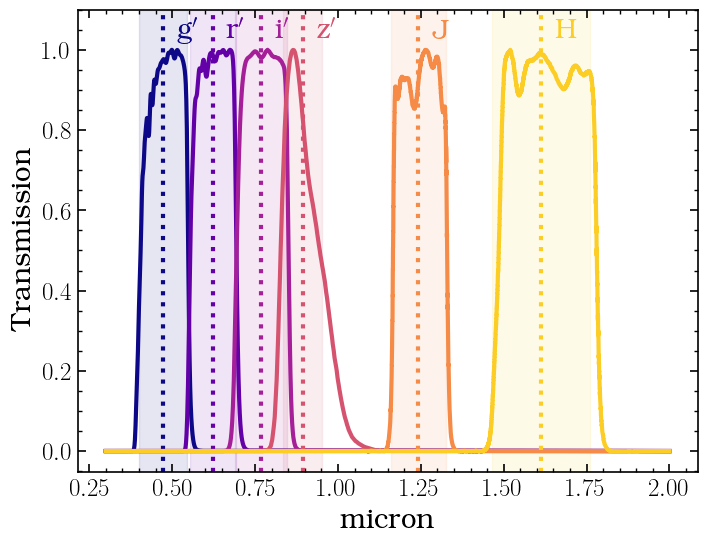

In [52]:
import matplotlib
cmap = matplotlib.colormaps.get_cmap('plasma')
fkeys = [key for key in filters.data_vars.keys()][:-1]
colors = cmap(np.linspace(0,0.9,len(fkeys)))
for i,key in enumerate(fkeys):
    color = colors[i]
    plt.plot(filters.wavelength, filters[key], color=color)
    plt.axvline(filters[key].effective_wavelength, color=color, ls=':')
    plt.axvspan(filters[key].effective_wavelength - filters[key].fwhm/2, filters[key].effective_wavelength + filters[key].fwhm/2,
               alpha = 0.1, color=color)
    plt.annotate(filters[key].label, 
                 xy=(filters[key].effective_wavelength,1.03), xytext = (10,0), textcoords = 'offset points', 
                 color=color, fontsize=20)
plt.ylim(top=1.1)
plt.xlabel(filters.wavelength.units)
plt.ylabel('Transmission')

The filters are on R=100,000 wavelength grid. You can easily multiply a filter by a spectrum by regridding the filter using the MeanRegrid function, or using the MultiplySpectrumByFilter function.

In [70]:
help(MultiplySpectrumByFilter)

Help on function MultiplySpectrumByFilter in module __main__:

MultiplySpectrumByFilter(spectrum, spectrumwavelength, filterkey)
    Multiply a filter transmission function by a model spectrum using the built in filter curves

    Args:
        spectrum (XArray): spectrum to be multiplied. Ex: model fpfs or planetflux
        spectrumwavelength (XArray): model wavelength array
        filterkey (str): Key for desired filter. Must be one of the keys from the LoadFilter() XArray

    Returns:
        arr: filter profile times spectrum



In [71]:
path = '/Volumes/Oy/ReflectX/ReflectXGasGiantGrid-R1000/'
Teff = 3500
Planet = 'Jupiter'
CtoO = 0.5
# Select some temperatures:
teqs = 150
# and phase and cloud properties:
phase = 90
fsed = 1
kzz = 1e9
model = LoadModel(path, Teff, planet, CtoO, 150, phase = 90, clouds = {'fsed':1, 'kzz':1e9})

Text(0, 0.5, 'Planet Flux [erg/cm**2/s/cm/]')

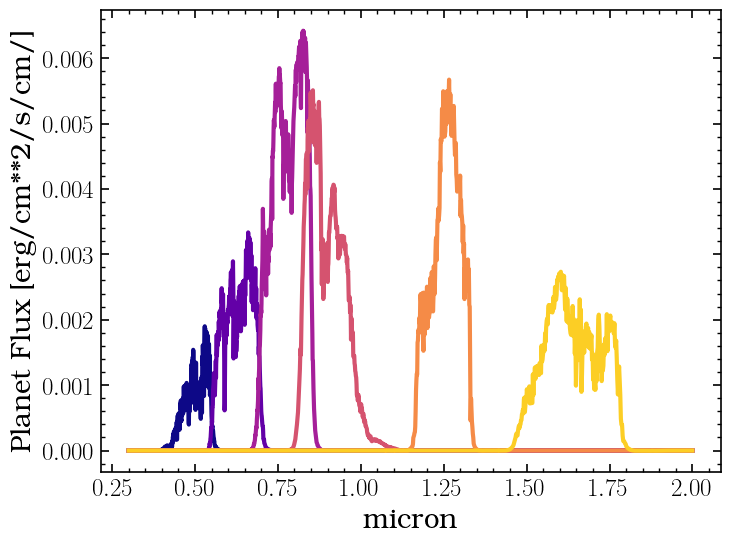

In [72]:
for i,key in enumerate(fkeys):
    color = colors[i]
    plt.plot(model.wavelength, MultiplySpectrumByFilter(model.planetflux, model.wavelength, key), color=color)
plt.xlabel(filters.wavelength.units)
plt.ylabel('Planet Flux [{}]'.format(model.planetflux.units))

Models are based on Phoenix stellar models which are defined as the flux from the stellar surface. To mimic an observation the models need to be scaled to the distance of the star.  Example: scale the above model to a star at 10 pc:

Text(0.5, 1.0, 'Planet flux leaving surface')

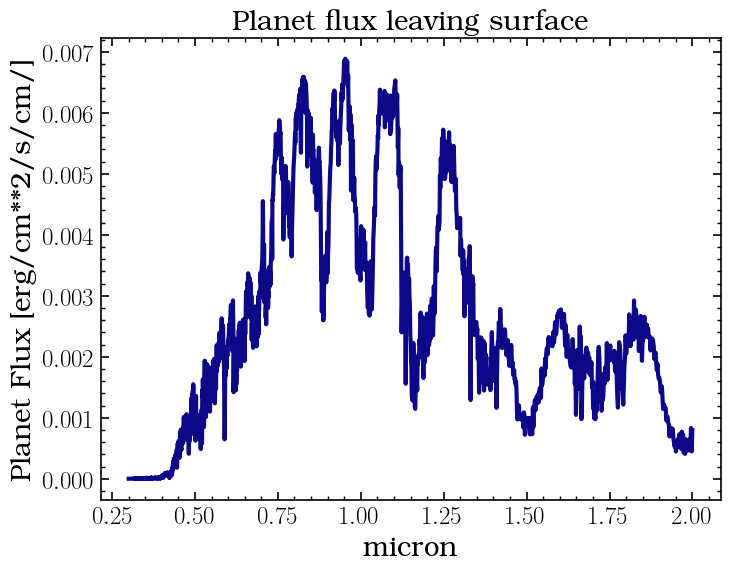

In [73]:
path = '/Volumes/Oy/ReflectX/ReflectXGasGiantGrid-R1000/'
Teff = 3500
Planet = 'Jupiter'
CtoO = 0.5
# Select some temperatures:
Teq = 150
# and phase and cloud properties:
phase = 90
fsed = 1
kzz = 1e9
model = LoadModel(path, Teff, planet, CtoO, Teq, phase = 90, clouds = {'fsed':1, 'kzz':1e9})
plt.plot(model.wavelength,model.planetflux)
plt.ylabel('Planet Flux [{}]'.format(model.planetflux.units))
plt.xlabel(model.wavelength.units)
plt.title('Planet flux leaving surface')

In [75]:
help(ScaleModelToStar)

Help on function ScaleModelToStar in module ReflectX.ReflectX:

ScaleModelToStar(model, distance)
    Scale star and planet flux arrays from surface to flux arriving at Earth

    Args:
        model (XArray): model XArray
        distance (float): distance to star in parsecs

    Returns:
        XArray: XArray of model with star and planet flux scaled to flux arriving at Earth



Text(0.5, 1.0, 'Planet flux arriving at Earth at 10 pc')

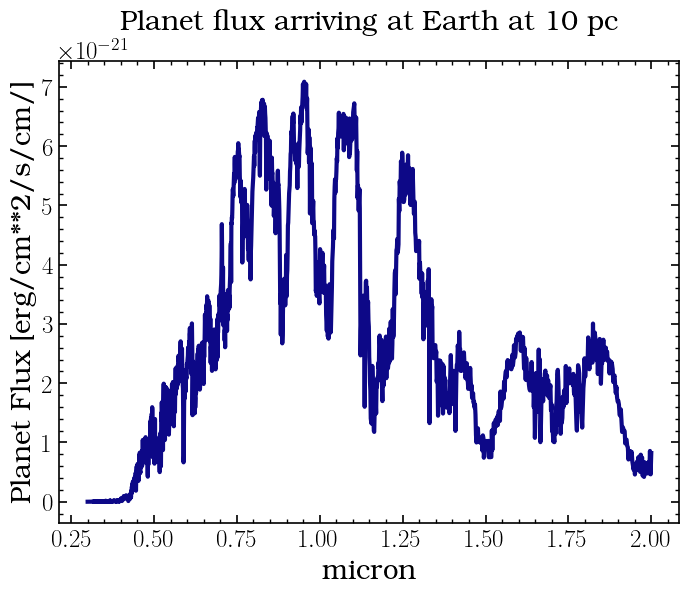

In [74]:
scaled_model = ScaleModelToStar(model, 10)

plt.plot(scaled_model.wavelength,scaled_model.planetflux)
plt.ylabel('Planet Flux [{}]'.format(scaled_model.planetflux.units))
plt.xlabel(scaled_model.wavelength.units)
plt.title('Planet flux arriving at Earth at 10 pc')

# ReflectX models beyond the grid

The initial ReflectX v1 release included a set of bespoke models specifically for GJ 876 b. The structure of the model dictionary anf XArrays is the same as the gas giant grid. We include a function for loading models outside the gas giant grid.

In [1]:
from ReflectX import *
help(LoadCustomModel)

Help on function LoadCustomModel in module ReflectX.ReflectX:

LoadCustomModel(filename)
    Function for loading a ReflectX model not part of the main grid. Ex: to load the bespoke GJ 876 b models of
    Pearce, Batalha, and Males 2026, model = LoadCustomModel(path+'ctoo{}-model.nc'.format(CtoO)) returns a dictionary
    of phase and cloud permutations.

    Args:
        filename (str): Complete path to model .nc file

    Returns:
        dict: Dictionary of ReflectX models contained in .nc file



In [9]:
CtoO = 15
path = '/Volumes/Oy/ReflectX/ReflectX-GJ876b-R1000/'
models = LoadCustomModel(path+'ctoo{}-model.nc'.format(CtoO))
phases = [p.split('/')[0].replace('phase','') for p in models.keys()]
phases = np.unique(np.array(phases))
phases

array(['100', '104', '109', '115', '119', '124', '130', '134', '139',
       '145', '149', '31', '34', '40', '45', '49', '55', '60', '64', '70',
       '75', '79', '85', '89', '94'], dtype='<U3')

In [10]:
phase = 89
fsed = 0.1
kzz = '1e+09'
model1 = models['phase{}/fsed{}/kzz{}'.format(phase,str(fsed).replace('.',''),kzz)]
fsed = 1
model2 = models['phase{}/fsed{}/kzz{}'.format(phase,str(fsed).replace('.',''),kzz)]
fsed = 6
model3 = models['phase{}/fsed{}/kzz{}'.format(phase,str(fsed).replace('.',''),kzz)]


Reproducing Figure from v1 paper:

[]

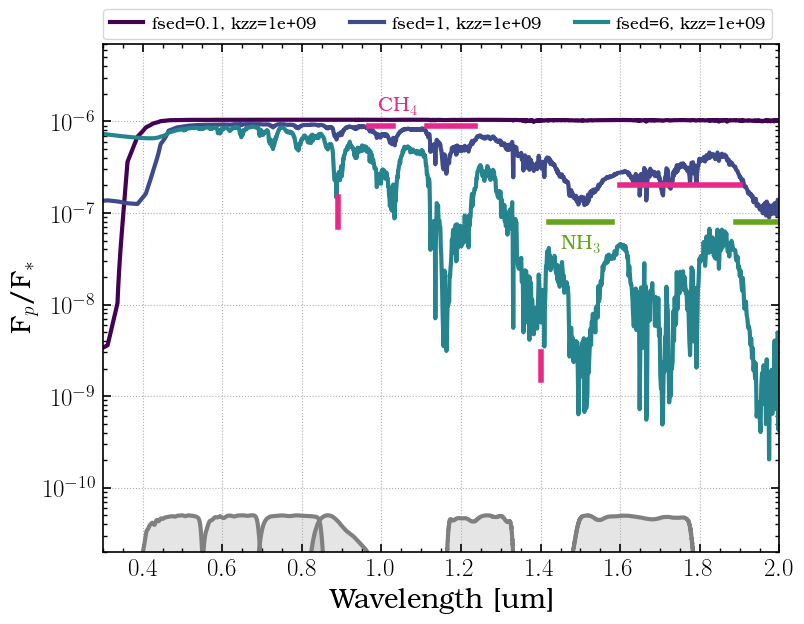

In [ ]:


import matplotlib as mpl
import matplotlib.pyplot as plt
def add_interval(ax, xdata, ydata, caps="  ", color='orange',lw=3):
    line = ax.add_line(mpl.lines.Line2D(xdata, ydata,lw=lw, color=color))
    anno_args = {
        'ha': 'center',
        'va': 'center',
        'size': 8,
        'color': line.get_color()
    }
    a0 = ax.annotate(caps[0], xy=(xdata[0], ydata[0]), **anno_args)
    a1 = ax.annotate(caps[1], xy=(xdata[1], ydata[1]), **anno_args)
    return (line,(a0,a1))

cmap = mpl.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0,0.9,5))
fseds = [0.1,1,6]
    
handles = []
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize=(8.2,6))

for i,model in enumerate([model1, model2, model3]):
    h, = axes.plot(model.wavelength, model.fpfs, color=colors[i], label='fsed={}, kzz={}'.format(fseds[i],kzz))
    handles.append(h)

ax = axes
cmap = mpl.colormaps.get_cmap('Dark2')
colors_spec = cmap(np.linspace(0,1,8))
color=colors_spec[3]
y = 2e-7
dy = 1.5e-7
x = 1.7
dx = 0.1
add_interval(ax, [x-0.1,x+0.2], (y,y), "  ", color=color, lw=4)


x = 1.4
dx = 0.08
y = 3e-9
dy = 1.5e-9
add_interval(ax, [x,x], (y-dy,y), "  ", color=color, lw=4)
# ax.annotate('CH$_4$',xy=(x,y-dy-0.7e-9), ha='center',color=color, fontsize=15)

x = 1.175
dx = 0.06
y = 0.9e-6
dy = 4e-7
add_interval(ax, [x-dx,x+dx], (y,y), "  ", color=color, lw=4)


x = 1.0
dx = 0.03
add_interval(ax, [x-dx,x+dx], (y,y), "  ", color=color, lw=4)
ax.annotate('CH$_4$',xy=(x+0.04,y+dy), ha='center',color=color, fontsize=15)


x = 0.89
dx = 0.02
y = 1.5e-7
dy = 0.8e-7
add_interval(ax, [x,x], (y-dy,y), "  ", color=color, lw=4)



color = colors_spec[4]
y = 8e-8
dy = -4e-8
x = 1.97
dx = 0.08
add_interval(ax, [x-dx,x+dx], (y,y), "  ", color=color, lw=4)


x = 1.5
dx = 0.08
add_interval(ax, [x-dx,x+dx], (y,y), "  ", color=color, lw=4)
ax.annotate('NH$_3$',xy=(x,y+dy), ha='center',color=color, fontsize=15)      

filters = LoadFilters()
filterkeys = [key for key in filters.data_vars.keys()][:-1]
for key in filterkeys:
    axes.plot(filters.wavelength,filters[key]*5e-11, color='grey')
    axes.fill_between(filters.wavelength, filters[key]*5e-11, 1e-11, color='grey', alpha=0.2)
    

axes.set_yscale('log')
axes.set_xlabel('Wavelength [um]')
axes.set_ylabel(r'F$_p$/F$_*$')
axes.grid(ls=':')
axes.set_xlim(0.3,2)
axes.set_ylim(bottom=2e-11, top=7e-6)
plt.tight_layout()

bigax = fig.add_subplot(111, frameon=False)
bigax.legend(handles = handles, loc=(0.001,1.01), ncol = 3, fontsize=12)
bigax.tick_params(top=False, bottom=False, left=False, right=False,
                labelleft=False, labelbottom=False)
bigax.set_xticks([], minor=True)
bigax.set_yticks([], minor=True)
#bigax.set_title('kzz='+kzz, y=1.1)
